In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

(array([ 2.,  1.,  0.,  3.,  4., 10.,  5., 24., 27., 16.]),
 array([0.72582053, 0.75317668, 0.78053282, 0.80788897, 0.83524511,
        0.86260126, 0.8899574 , 0.91731355, 0.94466969, 0.97202584,
        0.99938198]),
 <BarContainer object of 10 artists>)

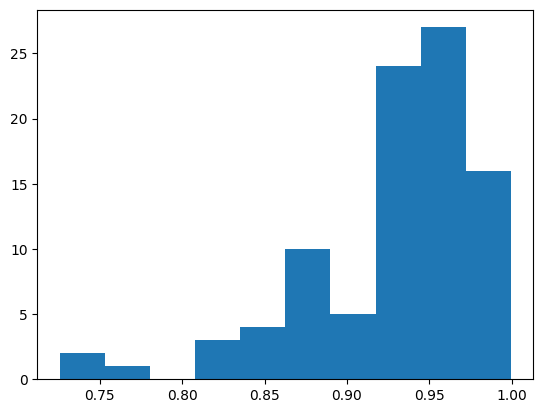

In [17]:
plt.hist(events["mass_ratio"])

In [2]:
posterior2 = np.load("./gw_posteriors/source_2/posterior.npz")

posterior2_mm = np.load("./gw_posteriors/source_2/posterior_mm.npz")


(array([343., 417., 513., 585., 555., 556., 534., 486., 433., 371.]),
 array([0.67127436, 0.70414236, 0.73701037, 0.76987837, 0.80274638,
        0.83561438, 0.86848239, 0.90135039, 0.9342184 , 0.9670864 ,
        0.99995441]),
 <BarContainer object of 10 artists>)

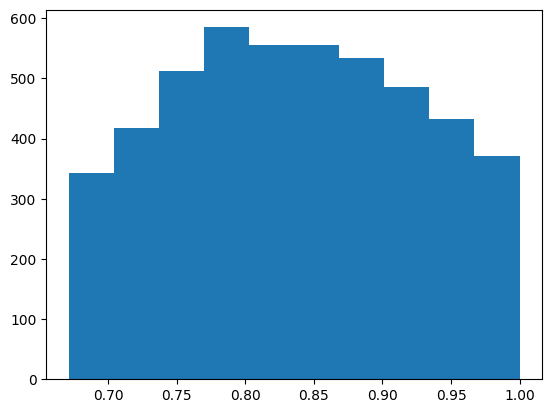

In [3]:
plt.hist(posterior2["mass_ratio"])

NameError: name 'posterior2_chirp' is not defined

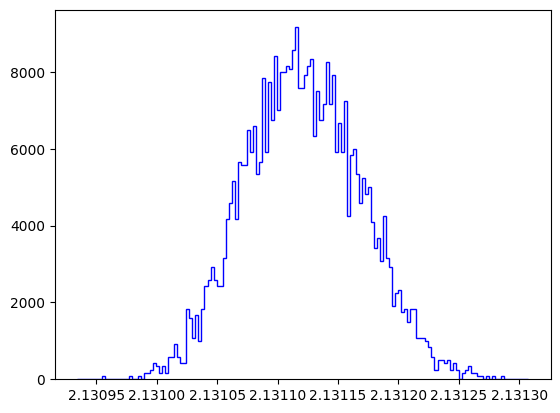

In [4]:
key = "chirp_mass"
bins = np.linspace(posterior2[key].min()*0.99999, posterior2[key].max()*1.00001, 150)

plt.hist(posterior2[key], histtype="step", bins=bins, density=True, color="blue")
plt.hist(posterior2_chirp[key], histtype="step", bins=bins, density=True, color="orange")
plt.hist(posterior2_source[key], histtype="step", bins=bins, density=True, color="green")

plt.hist(posterior2_mm[key], histtype="step", bins=bins, density=True, color="blue", linestyle='dashed')
plt.hist(posterior2_chirp_mm[key], histtype="step", bins=bins, density=True, color="orange", linestyle='dashed')
plt.hist(posterior2_source_mm[key], histtype="step", bins=bins, density=True, color="green", linestyle='dashed')
plt.vlines([events.loc[2, key]], *plt.gca().get_ylim(), color="red")

In [ ]:
def quantile_list(key):
    quantiles = np.zeros(92)
    for j in range(92):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("mass_1_source")
quantiles_detector = quantile_list("mass_1")
quantiles_chirp = quantile_list('chirp_mass')
quantiles_mass_ratio = quantile_list('mass_ratio')

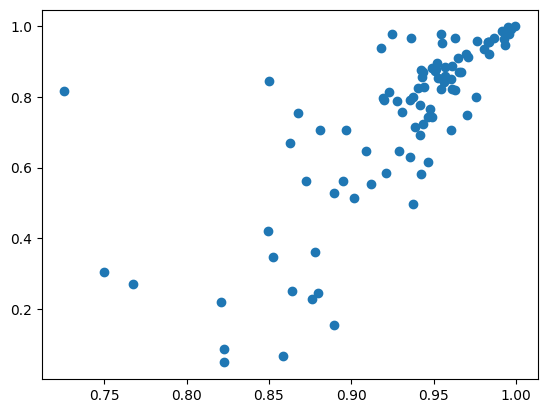

In [10]:
plt.scatter(events["mass_ratio"], quantiles_mass_ratio)

Text(0.5, 0, 'chirp mass quantiles')

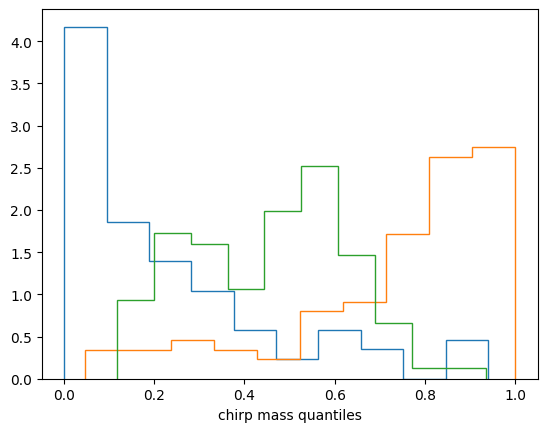

In [16]:

plt.hist(quantiles_chirp, histtype="step", density=True)
plt.hist(quantiles_mass_ratio, histtype="step", density=True)
plt.hist(quantile_list("chi_1"), histtype="step", density=True)
plt.xlabel("chirp mass quantiles")

(array([ 30.,  60.,  65.,  86.,  94., 124., 143., 122., 135., 141.]),
 array([0.50767442, 0.55690607, 0.60613772, 0.65536937, 0.70460103,
        0.75383268, 0.80306433, 0.85229598, 0.90152763, 0.95075928,
        0.99999093]),
 <BarContainer object of 10 artists>)

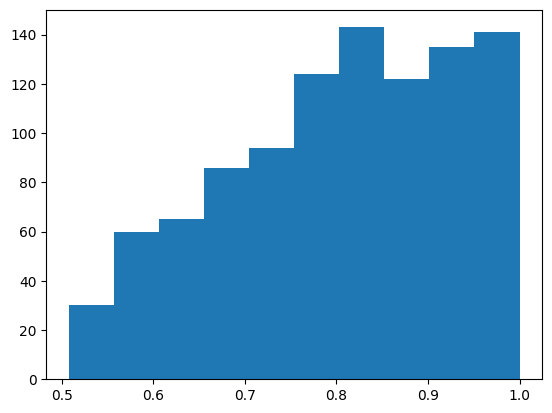

In [20]:
x = np.random.uniform(1, 2, size=1000)
y = np.random.uniform(1, 2, size=1000)
x, y = np.maximum(x, y), np.minimum(x, y)

plt.hist(y/x)

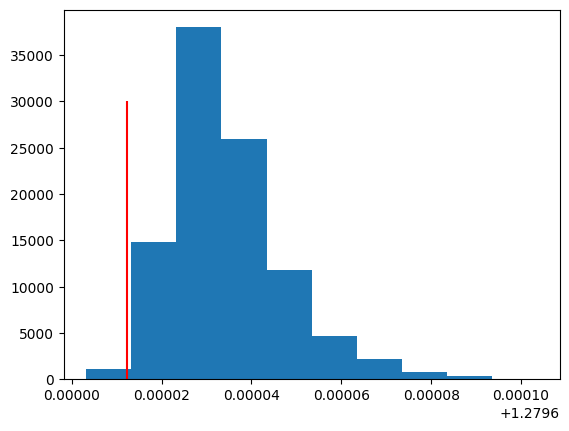

In [44]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [7]:
quantiles.max()

np.float64(0.9689296)

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [22]:
events["mass_ratio"].min()

np.float64(0.7258205335293277)